In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from module.Architecture import ANN


In [2]:
Transform = transforms.ToTensor()

In [3]:
train_data = datasets.EMNIST(root="./data/ANN",split="balanced",train=True, download=True, transform=Transform)
train_data

Dataset EMNIST
    Number of datapoints: 112800
    Root location: ./data/ANN
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
image, label = train_data[9]
print(image.shape, label)


torch.Size([1, 28, 28]) 1


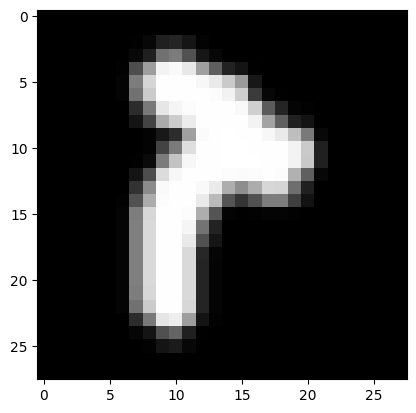

In [5]:
plt.imshow(train_data[0][0].reshape(28,28), cmap="gray")

In [6]:
test = datasets.EMNIST(root="./data/ANN", split="balanced", train=False, download=True, transform=Transform)

test

Dataset EMNIST
    Number of datapoints: 18800
    Root location: ./data/ANN
    Split: Test
    StandardTransform
Transform: ToTensor()

In [14]:
import torch.optim as optim

# Tracking metrics
train_losses = []
train_accuracies = []

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

model = ANN(28*28, [128, 64, 32], 47)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):
    epoch_loss = 0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(100 * correct_train / total_train)
    print(f"Epoch {epoch+1}, Loss: {train_losses[-1]:.4f}, Accuracy: {train_accuracies[-1]:.2f}%")

Epoch 1, Loss: 1.1724, Accuracy: 65.34%
Epoch 2, Loss: 0.6798, Accuracy: 78.04%
Epoch 3, Loss: 0.5783, Accuracy: 80.77%
Epoch 4, Loss: 0.5232, Accuracy: 82.23%
Epoch 5, Loss: 0.4874, Accuracy: 83.20%
Epoch 6, Loss: 0.4609, Accuracy: 84.04%
Epoch 7, Loss: 0.4401, Accuracy: 84.60%
Epoch 8, Loss: 0.4233, Accuracy: 85.14%
Epoch 9, Loss: 0.4097, Accuracy: 85.39%
Epoch 10, Loss: 0.3982, Accuracy: 85.67%


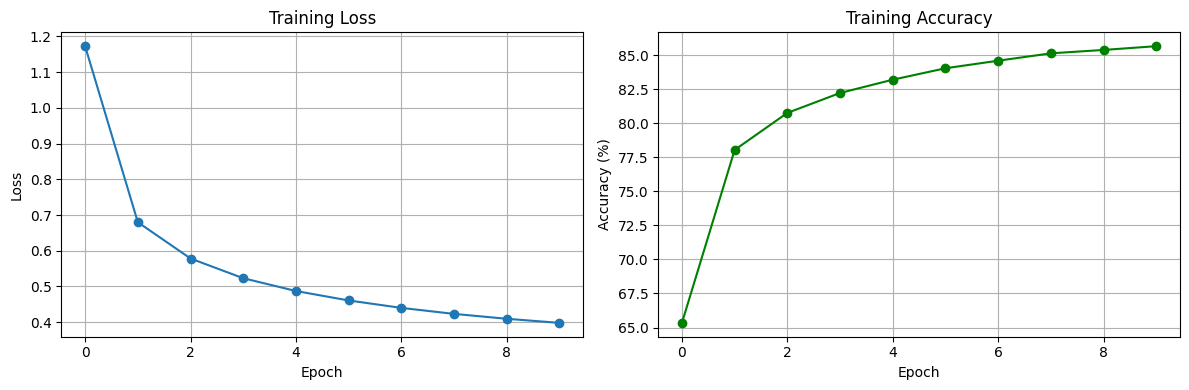

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid()

ax2.plot(train_accuracies, marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid()

plt.tight_layout()
plt.show()

In [16]:
# Get all predictions and labels
all_predictions = []
all_labels = []
all_images = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_images.extend(images.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_images = np.array(all_images)

# Test accuracy
test_accuracy = 100 * np.sum(all_predictions == all_labels) / len(all_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 82.61%


[[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
    14   15   16   17   18   19   20   21   22   23   24   25   26   27
    28   29   30   31   32   33   34   35   36   37   38   39   40   41
    42   43   44   45   46]]



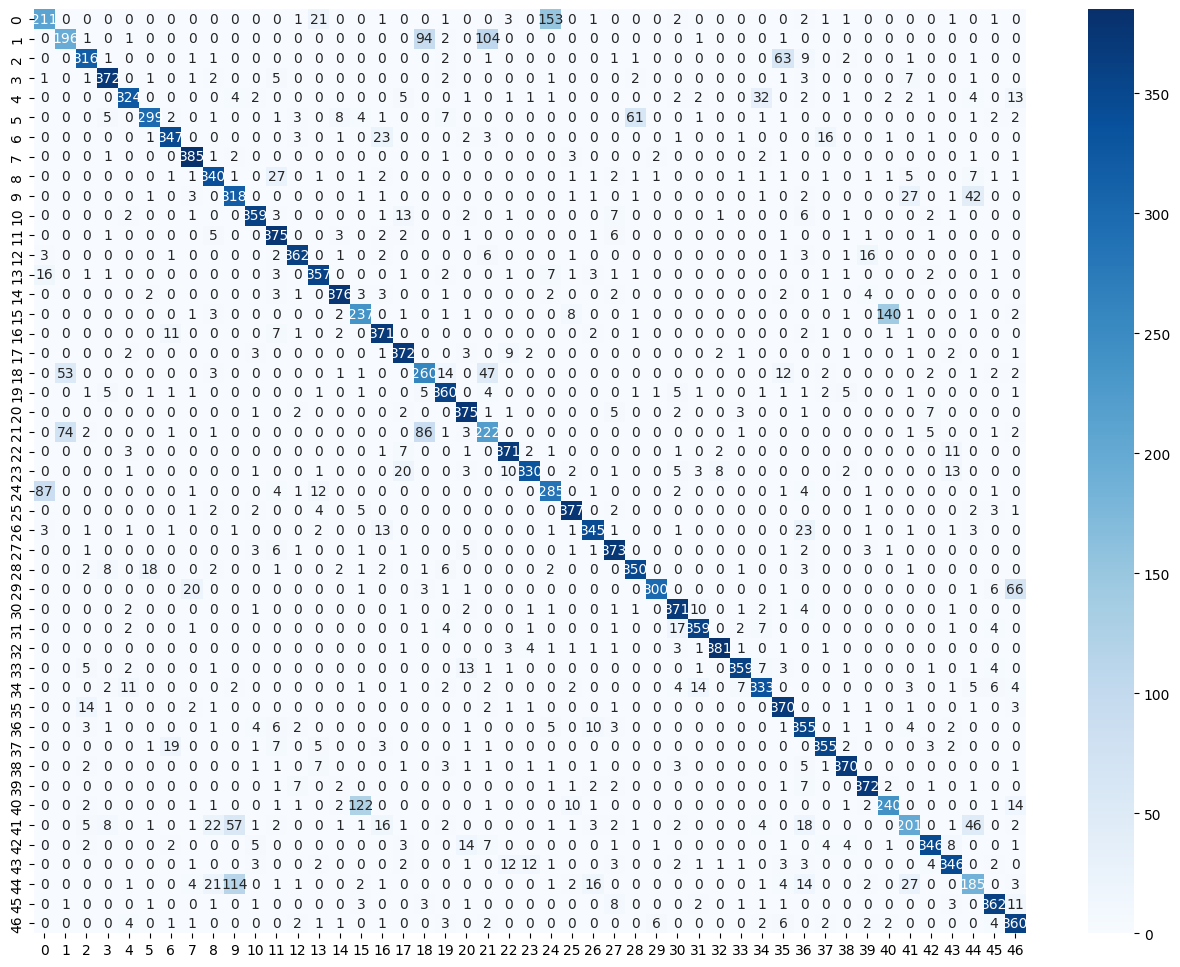

In [40]:
np.set_printoptions(formatter=dict(int=lambda x: f"{x:4}"))
print(np.arange(47).reshape(1,-1))
print()

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [20]:
# Find misclassifications
errors = all_predictions != all_labels
error_indices = np.where(errors)[0]

print(f"Total errors: {len(error_indices)} out of {len(all_labels)}")
print("\nTop 10 most common errors:")

error_pairs = [(all_labels[i], all_predictions[i]) for i in error_indices]
from collections import Counter
most_common_errors = Counter(error_pairs).most_common(10)

for (true_label, pred_label), count in most_common_errors:
    print(f"True: {true_label}, Predicted: {pred_label} -> {count} times")

Total errors: 3270 out of 18800

Top 10 most common errors:
True: 0, Predicted: 24 -> 153 times
True: 15, Predicted: 40 -> 140 times
True: 40, Predicted: 15 -> 122 times
True: 44, Predicted: 9 -> 114 times
True: 1, Predicted: 21 -> 104 times
True: 1, Predicted: 18 -> 94 times
True: 24, Predicted: 0 -> 87 times
True: 21, Predicted: 18 -> 86 times
True: 21, Predicted: 1 -> 74 times
True: 29, Predicted: 46 -> 66 times


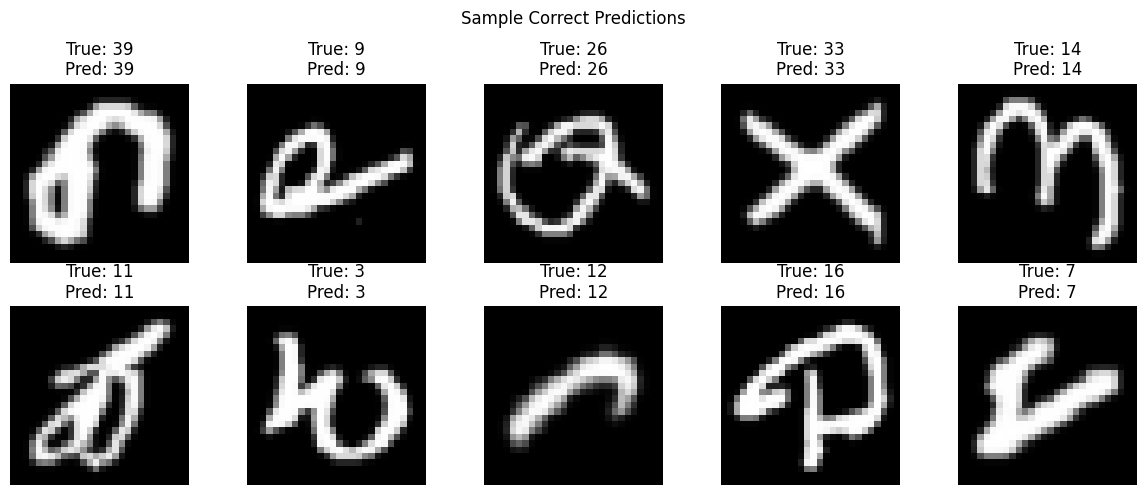

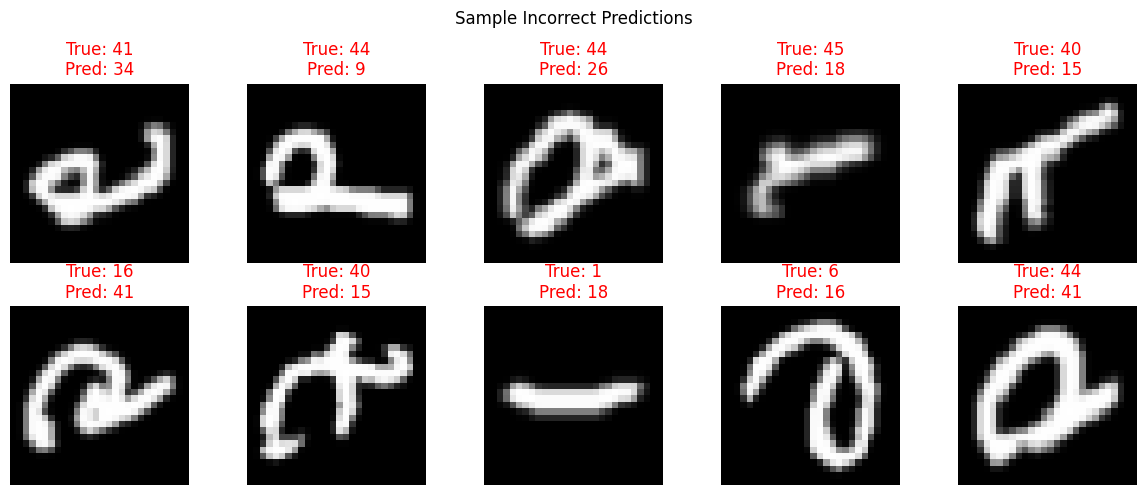

In [21]:
# Show correct predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Correct Predictions')

correct_indices = np.where(all_predictions == all_labels)[0][:10]
for idx, ax in enumerate(axes.flatten()):
    img_idx = correct_indices[idx]
    image = all_images[img_idx].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"True: {all_labels[img_idx]}\nPred: {all_predictions[img_idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Show incorrect predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Incorrect Predictions')

error_indices = np.where(all_predictions != all_labels)[0][:10]
for idx, ax in enumerate(axes.flatten()):
    img_idx = error_indices[idx]
    image = all_images[img_idx].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"True: {all_labels[img_idx]}\nPred: {all_predictions[img_idx]}", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_predictions, 
                           target_names=[str(i) for i in range(47)]))

              precision    recall  f1-score   support

           0       0.66      0.53      0.59       400
           1       0.60      0.49      0.54       400
           2       0.88      0.79      0.83       400
           3       0.92      0.93      0.92       400
           4       0.91      0.81      0.86       400
           5       0.92      0.75      0.82       400
           6       0.90      0.87      0.88       400
           7       0.90      0.96      0.93       400
           8       0.83      0.85      0.84       400
           9       0.64      0.80      0.71       400
          10       0.93      0.90      0.91       400
          11       0.82      0.94      0.88       400
          12       0.93      0.91      0.92       400
          13       0.86      0.89      0.88       400
          14       0.94      0.94      0.94       400
          15       0.62      0.59      0.60       400
          16       0.83      0.93      0.88       400
          17       0.86    